## Support Vector Machine Classifier

In this part we classify the deposits with a support vector machine (SVM), as in the TD4: the SVM looks for the boundary between the two classes with the largest margin, allows some deposits inside the margin or on the wrong side at a cost set by `C`, and draws a non-linear boundary through a kernel. The deposits, their inputs and their label are those of the naive Bayes notebook (`deposit_data`).

### Main observations

- **Linear kernel:** F1 of 0.78 at best (C = 316), and 45% of the deposits are still support vectors with a large C: the two classes overlap a lot with a linear boundary.
- **Non-linear kernels:** The RBF kernel reaches 0.84 on a wide plateau (`gamma` from 0.01 to 0.3, C of 10 or more). As in the TD4, a too small C predicts every deposit conforming, and a too large `gamma` learns the training deposits by heart. The polynomial kernel of degree 2 does as well (0.84 with C = 100) and is the one selected.
- **Results:** F1 of 0.84 and recall of 0.83. The SVM catches 69 of the 83 non-conforming deposits, for 12 false alarms. This is the F1 of the Extra-Trees of `1B`, the best regression model on the label, with 11 more points of recall (0.72 for the Extra-Trees).
- **Nested cross-validation:** F1 of 0.85. The plateau of good hyperparameters is wide, so choosing them on the same folds as the evaluation inflates nothing, unlike for the naive Bayes and the k-NN.

### Operations in order

1. Load the train set with `load_train` and the labelled deposits with `get_deposit_xy`.
2. Tune the kernel, `C`, `gamma` (RBF kernel) and the degree (polynomial kernel) by a grid search on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score.
3. Plot the train and validation F1 and the share of support vectors against `C` for the linear kernel.
4. Plot the validation F1 of the RBF kernel for each pair (`gamma`, `C`), and give that of the polynomial kernel.
5. Compare the best model of each kernel.
6. Evaluate the best model with `evaluate_label`, and check its F1 by nested cross-validation.
7. Save it to `results.csv` and compare it with the other models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    load_train, get_deposit_xy, build_pipeline,
    oof_predict_label, nested_oof_predict_label, evaluate_label, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()
X, y, cv = get_deposit_xy(train)

print(X.shape, "| non-conforming:", y.sum())

(175, 32) | non-conforming: 83


In [4]:
C_values = np.logspace(-3, 4, 15)
gamma_values = np.logspace(-4, 1, 11)

search = GridSearchCV(
    build_pipeline(SVC()),
    [
        {"model__kernel": ["linear"], "model__C": C_values},
        {"model__kernel": ["rbf"], "model__C": C_values, "model__gamma": gamma_values},
        {"model__kernel": ["poly"], "model__C": C_values, "model__degree": [2, 3], "model__coef0": [1]},
    ],
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1,
).fit(X, y)

cv_results = pd.DataFrame(search.cv_results_)
print(len(cv_results), "candidates")

210 candidates


A single grid search covers the three kernels of the TD4, with a list of grids: the linear kernel $x^\top x'$, the RBF kernel $\exp(-\gamma \lVert x - x' \rVert^2)$ and the polynomial kernel $(\gamma\, x^\top x' + 1)^d$ (`coef0 = 1` as advised in the TD4, and the default `gamma`). `C` goes from 0.001 to 10,000 and `gamma` from 0.0001 to 10, on log scales. As for the k-NN, the inputs are standardised by `build_pipeline`, the RBF kernel being a function of the Euclidean distance between deposits. The next cells read the 210 results of this search.

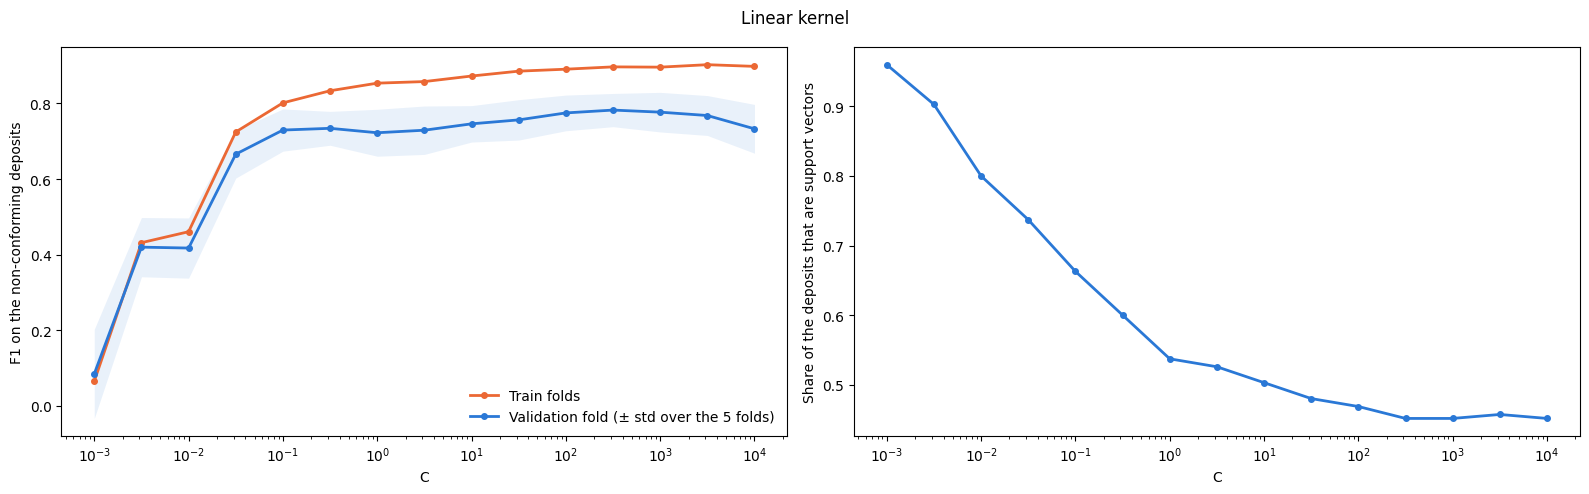

In [5]:
linear = cv_results[cv_results["param_model__kernel"] == "linear"]
support = [build_pipeline(SVC(kernel="linear", C=C)).fit(X, y)["model"].n_support_.sum() / len(X) for C in C_values]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].fill_between(C_values, linear["mean_test_score"] - linear["std_test_score"], linear["mean_test_score"] + linear["std_test_score"], color="#2a78d6", alpha=0.1, linewidth=0)
axes[0].plot(C_values, linear["mean_train_score"], color="#eb6834", linewidth=2, marker="o", markersize=4, label="Train folds")
axes[0].plot(C_values, linear["mean_test_score"], color="#2a78d6", linewidth=2, marker="o", markersize=4, label="Validation fold (± std over the 5 folds)")
axes[0].set_ylabel("F1 on the non-conforming deposits")
axes[0].legend(frameon=False)
axes[1].plot(C_values, support, color="#2a78d6", linewidth=2, marker="o", markersize=4)
axes[1].set_ylabel("Share of the deposits that are support vectors")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("C")
fig.suptitle("Linear kernel")
plt.tight_layout()
plt.show()

- **C:** The cost of a deposit inside the margin or on the wrong side of the boundary. With C of 0.01 or less, the margin is so wide that the SVM predicts almost every deposit conforming (validation F1 of 0.08 to 0.42). The F1 rises with C up to 0.78 at C = 316, then goes down a little as the boundary follows the training deposits more and more (train F1 of 0.90).
- **Support vectors:** The deposits inside the margin or misclassified, which alone define the boundary. They are 96% of the deposits at C = 0.001, and still 45% from C = 316 on: with a linear boundary, almost half of the deposits are on the wrong side or too close to it. The two classes are far from linearly separable with these 32 inputs.

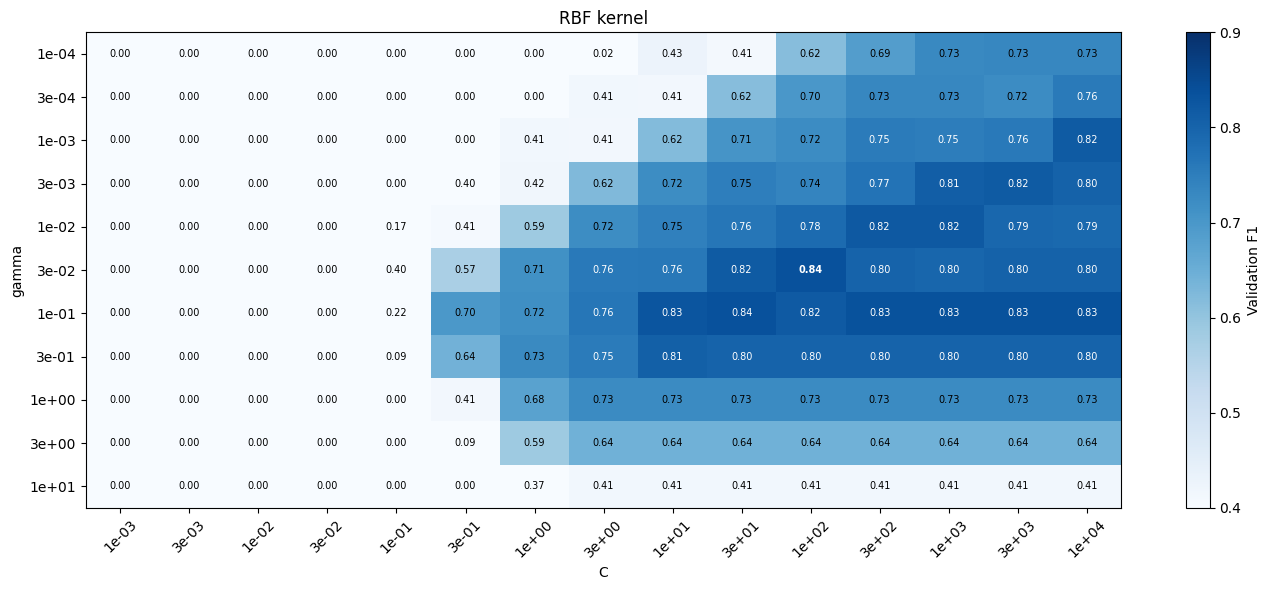

In [6]:
rbf = cv_results[cv_results["param_model__kernel"] == "rbf"].pivot(index="param_model__gamma", columns="param_model__C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(rbf, cmap="Blues", vmin=0.4, vmax=0.9, aspect="auto")
ax.set_xticks(range(len(C_values)), [f"{C:.0e}" for C in rbf.columns], rotation=45)
ax.set_yticks(range(len(gamma_values)), [f"{gamma:.0e}" for gamma in rbf.index])
for i in range(rbf.shape[0]):
    for j in range(rbf.shape[1]):
        value = rbf.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if value > 0.75 else "black",
                fontweight="bold" if value == rbf.values.max() else "normal")
ax.set_xlabel("C")
ax.set_ylabel("gamma")
fig.colorbar(im, ax=ax, label="Validation F1")
ax.set_title("RBF kernel")
plt.tight_layout()
plt.show()

The validation F1 of each pair (`gamma`, `C`) of the RBF kernel, the best one in bold.

- **Small C (0.1 or less):** F1 of 0 on most of the left part. The margin is so wide that every deposit is predicted conforming, the majority class.
- **Large gamma (3 or more):** F1 of 0.64 or less whatever C. Each training deposit only influences a tiny region around itself, so the new deposits are far from all of them and get the same class (0.64 is the F1 of the rule that declares every deposit non-conforming): the overfitting of the TD4 (question 10).
- **Small gamma (0.0001):** The kernel is almost linear and needs a large C, with at best the F1 of the linear kernel (0.73).
- **Plateau:** With `gamma` from 0.01 to 0.3 and C of 10 or more, the F1 is between 0.75 and 0.84, above 0.80 for most pairs. The best pair (`gamma` = 0.03, C = 100) is one of many equivalent ones.

In [7]:
poly = cv_results[cv_results["param_model__kernel"] == "poly"]
poly.pivot(index="param_model__C", columns="param_model__degree", values="mean_test_score").rename_axis(index="C", columns="degree").round(3)

degree,2.0,3.0
C,,
0.001000,0.022,0.022
0.003162,0.022,0.160
0.010000,0.284,0.402
0.031623,0.402,0.402
0.100000,0.402,0.546
0.316228,0.681,0.730
1.000000,0.739,0.780
3.162278,0.799,0.782
10.000000,0.783,0.838


The validation F1 of the polynomial kernel of degree 2 and 3 for each C.

- **Degree 2:** 0.84 at C = 100, the best of the whole grid. With `coef0 = 1`, this kernel amounts to a linear boundary on the inputs and on all the products of two inputs, so the boundary can use the interactions between inputs.
- **Degree 3:** 0.84 at C = 10, then down to 0.77 to 0.79 for larger C: a more flexible boundary follows the training deposits sooner. The degree acts as a regularisation parameter, as in the TD4 (question 6).

In [8]:
best_per_kernel = cv_results.loc[cv_results.groupby("param_model__kernel")["mean_test_score"].idxmax()]
best_per_kernel = best_per_kernel.set_index("param_model__kernel")[["param_model__C", "param_model__gamma", "param_model__degree", "mean_train_score", "mean_test_score", "std_test_score"]]
best_per_kernel.columns = ["C", "gamma", "degree", "train_F1", "validation_F1", "validation_F1_std"]
display(best_per_kernel)

print(search.best_params_)

,C,gamma,degree,train_F1,validation_F1,validation_F1_std
param_model__kernel,,,,,,
linear,316.227766,NaN,NaN,0.896405,0.782212,0.043894
poly,100.000000,NaN,2.0,0.964397,0.840807,0.048787
rbf,100.000000,0.031623,NaN,0.980713,0.837294,0.042675


{'model__C': np.float64(100.0), 'model__coef0': 1, 'model__degree': 2, 'model__kernel': 'poly'}


- **Non-linear kernels:** The polynomial and RBF kernels are equivalent (0.841 and 0.837, with a standard deviation of 0.04 to 0.05 over the folds), 0.06 above the linear kernel. The grid search keeps the polynomial kernel of degree 2 with C = 100, by 0.004 of F1, much less than the noise.
- **Train F1:** 0.96 for the polynomial kernel and 0.98 for the RBF kernel, against 0.84 on the validation fold: as the k-NN with one neighbour, the best models follow the training deposits closely.

In [9]:
best = search.best_estimator_

svm = evaluate_label("SVM classifier", best, train)
display(svm.dropna(axis=1, how="all").round(2))

oof = oof_predict_label(best, train)
print("Support vectors when fitted on the 175 deposits:", build_pipeline(best).fit(X, y)["model"].n_support_)
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

,model,target,family,n_clf,n_nc,F1_nc,recall_nc,accuracy
0,SVM classifier,label,all,175,83,0.84,0.83,0.85
1,SVM classifier,label,C-Mn,161,79,0.85,0.84,0.86
2,SVM classifier,label,CrMo2,8,1,0.67,1.00,0.88
3,SVM classifier,label,CrMo91,6,3,0.67,0.67,0.67


Support vectors when fitted on the 175 deposits: [38 32]


,predicted conforming,predicted non-conforming
conforming,80,12
non-conforming,14,69


- **All deposits:** F1 of 0.84 and recall of 0.83: 69 of the 83 non-conforming deposits are caught, for 12 false alarms out of 92 conforming deposits (a precision of 0.85).
- **Support vectors:** 70 of the 175 deposits (38 conforming and 32 non-conforming) when the model is fitted on all the deposits: 40% of the deposits define the boundary.
- **Per family:** The single non-conforming CrMo2 deposit is caught, with one false alarm among the 7 others, and 2 of the 3 non-conforming CrMo91 deposits.

In [10]:
nested_pred, nested_params = nested_oof_predict_label(search, train)

print("Nested F1:", round(f1_score(y, nested_pred), 3), "| recall:", round(recall_score(y, nested_pred), 3))
nested_params

Nested F1: 0.845 | recall: 0.855


,C,gamma,kernel,coef0,degree
fold,,,,,
0,316.227766,0.031623,rbf,NaN,NaN
1,100.000000,0.031623,rbf,NaN,NaN
2,100.000000,0.010000,rbf,NaN,NaN
3,316.227766,0.010000,rbf,NaN,NaN
4,100.000000,NaN,poly,1.0,2.0


The same nested cross-validation as in the other notebooks: the grid search of the 3 kernels is redone for each fold on the 4 other folds only.

- **Nested F1:** 0.85 and recall of 0.86, the same as without nesting (0.84 and 0.83). The RBF kernel is chosen for 4 folds (C of 100 or 316, `gamma` of 0.01 or 0.03) and the polynomial kernel of degree 2 for the fifth, all on the plateau of the figure above. Choosing the hyperparameters on the same folds does not inflate the F1 of the SVM.

In [11]:
results = save_results(svm)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees", "Naive Bayes classifier", "k-NN classifier", "SVM classifier"]
label = results[(results["target"] == "label") & results["model"].isin(models)]
label.pivot(index="model", columns="family", values=["F1_nc", "recall_nc", "accuracy"]).reindex(index=models).reindex(columns=["all", "C-Mn", "CrMo2", "CrMo91"], level="family").round(2)

F1_nc                    recall_nc                     \
family                   all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91   
model                                                                          
Baseline (mean)         0.00  0.00  0.00   0.00      0.00  0.00   0.0   0.00   
Pruned CART             0.77  0.78  1.00   0.00      0.81  0.84   1.0   0.00   
Bagging                 0.81  0.83  0.00   0.50      0.72  0.75   0.0   0.33   
Random forest           0.76  0.77  0.00   0.50      0.64  0.66   0.0   0.33   
Extra-Trees             0.84  0.85  0.00   0.80      0.72  0.73   0.0   0.67   
Naive Bayes classifier  0.70  0.71  0.00   0.50      0.69  0.70   0.0   0.67   
k-NN classifier         0.80  0.81  1.00   0.50      0.82  0.82   1.0   0.67   
SVM classifier          0.84  0.85  0.67   0.67      0.83  0.84   1.0   0.67   

                       accuracy                     
family                      all  C-Mn CrMo2 CrMo91  
model                                               
Baseline (mean)            0.53  0.51  0.88   0.50  
Pruned CART                0.77  0.77  1.00   0.33  
Bagging                    0.84  0.84  0.88   0.67  
Random forest              0.81  0.81  0.88   0.67  
Extra-Trees                0.87  0.87  0.88   0.83  
Naive Bayes classifier     0.72  0.73  0.88   0.33  
k-NN classifier            0.81  0.81  1.00   0.33  
SVM classifier             0.85  0.86  0.88   0.67

The SVM has the best F1 of the table, level with the Extra-Trees of `1B` (0.84), and a recall of 0.83, above every regression model (0.64 to 0.81). It is the first direct classifier that does as well as the four regressions and the thresholds on the F1, and it catches more bad welds.